# Variantional Auto Encoder (VAE)

- [Insightful explaination (Bilibili)](https://www.bilibili.com/video/BV1Uj411Y7Zq/?spm_id_from=333.337.search-card.all.click&vd_source=25b9d402791c6cace8dfb973938b3a69)
- [More Mathematical but short (LiL's blog)](https://lilianweng.github.io/posts/2018-08-12-vae/)
- [more rigorous go throuth with many math (I like it personaly)](https://mbernste.github.io/posts/vae/)

In [9]:
import numpy as np
import scipy.stats
import torch

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
%matplotlib inline

# Target Distribution

- Assume that we have a distribution from which we want to sample some data. 
- But We don\'t know what exactly it is. 
- Assume this underline distribution is a mixture of gaussin.

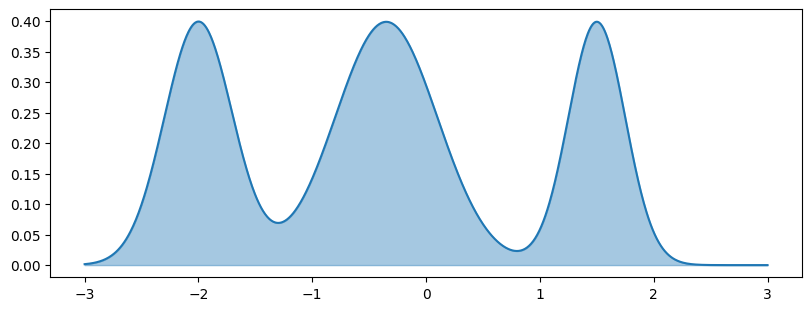

In [49]:
mixture_prob = np.array([0.45, 0.25, 0.3], dtype=float)  # Mixture weights
mixture_mus = np.array([-0.35, 1.5, -2], dtype=float)  # Means of the two Gaussian modes
mixture_sigmas = np.array([0.45, 0.25, 0.30], dtype=float)  # Standard deviations of the modes

def mixture_pdf(x: np.ndarray) -> np.ndarray:
    """Compute the PDF of a mixture of Gaussians."""
    comps = scipy.stats.norm.pdf(x[None, :], loc=mixture_mus[:, None], scale=mixture_sigmas[:, None])
    return np.sum(mixture_prob[:, None] * comps, axis=0)


def mixture_sample(size: int) -> np.ndarray:
    """Sample from a mixture of Gaussians."""
    rand_idx = np.random.choice(range(len(mixture_prob)), size=size, p=mixture_prob)
    means = mixture_mus[rand_idx]
    stds = mixture_sigmas[rand_idx]
    return np.random.normal(loc=means, scale=stds)
 
x_all_steps = np.linspace(-3, 3, 1000)
pdf_target = mixture_pdf(x=x_all_steps)

fig, ax = plt.subplots(1, 1, figsize=(8, 3), constrained_layout=True, dpi=100)

ax.plot(x_all_steps, pdf_target, label="PDF Target π₁", color="tab:blue")
ax.fill_between(x_all_steps, pdf_target, alpha=0.4, color="tab:blue")

# models

- Assume we have latent space $z \sim \mathcal{N}(0, 1)$
- we build probabilistic decoder to represent $p_{\theta}(x|z)$, parameterized by $\theta$. 
- It is helpful because we can represent $p(x) = \int p_\theta(x_i \mid z_i)\, p(z_i)\, dz_i $


In [78]:
latent_dim = 4

decoder = torch.nn.Sequential(
    torch.nn.Linear(latent_dim, 8),
    torch.nn.Tanh(),
    torch.nn.Linear(8, 16),
    torch.nn.Tanh(),
    torch.nn.Linear(16, 1)
)

# Problems

- It is hard to measure $p_{\theta}(x)$ because we can not integral the $dz$
- As a result, we can not compute the $p_{\theta}(x)$ for maxisum likelyhood estimation

# Variation Inference

Let's say the posterior distribution is $p_{\theta}(z|x)$

OK, this can not be compute because:

$$
p_\theta(z_i \mid x_i)
=
\frac{
p_\theta(x_i \mid z_i)\, p(z_i)
}{
\int p_\theta(x_i \mid z_i)\, p(z_i)\, \mathrm{d}z_i
}
$$

Next, we build a model $q_{\phi}(x)$ to approximate this truth $p_{\theta}(z|x)$. Apparently, we want push them close. So we use KL divergence $D_{\mathrm{KL}}\big(q_\phi(\mathbf{z}|\mathbf{x}) \,\|\, p_\theta(\mathbf{z}|\mathbf{x})\big)$

# Some Math

$$
\log p_\theta(\mathbf{x})
-
D_{\mathrm{KL}}\big(q_\phi(\mathbf{z}|\mathbf{x}) \,\|\, p_\theta(\mathbf{z}|\mathbf{x})\big)
=
\mathbb{E}_{\mathbf{z}\sim q_\phi(\mathbf{z}|\mathbf{x})}
\big[\log p_\theta(\mathbf{x}|\mathbf{z})\big]
-
D_{\mathrm{KL}}\big(q_\phi(\mathbf{z}|\mathbf{x}) \,\|\, p_\theta(\mathbf{z})\big)
$$

The right part is ELBO, there are some important points:

- Assume $\theta$ is fixed, maximize ELBO is equivalent to minize $D_{\mathrm{KL}}\big(q_\phi(\mathbf{z}|\mathbf{x}) \,\|\, p_\theta(\mathbf{z}|\mathbf{x})\big)$
- We also joint optimize $\theta$ and $\phi$. Why this is reasonable? Because ELBO is a lowerbound of $\log p_\theta(\mathbf{x})$

In [79]:
# let build this approximation model
# It estimate mean and logvar of latent z
encoder = torch.nn.Sequential(
    torch.nn.Linear(1, 16),
    torch.nn.Tanh(),
    torch.nn.Linear(16, 8),
    torch.nn.Tanh()
)

encoder_mean = torch.nn.Linear(8, latent_dim)
encoder_logvar = torch.nn.Linear(8, latent_dim)

# Optimization Objective

$$
L =  \mathrm{MSE}(\hat x, x) + D_{\mathrm{KL}}\big(q_\phi(\mathbf{z}|\mathbf{x}) \,\|\, p(\mathbf{z})\big) = \frac{1}{2}(\hat x_{\theta,\phi} - x)^2 + \frac{1}{2}(\mu_{\phi}^2 - 1 + \sigma_{\phi}^2 - log\sigma_{\phi}^2)
$$


In [80]:
param_groups = [
    {"params": decoder.parameters()},
    {"params": encoder.parameters()},
    {"params": encoder_mean.parameters()},
    {"params": encoder_logvar.parameters()}
]

optimizer = torch.optim.Adam(param_groups, lr=1e-4)

# Lets  training our model

In [81]:

batch_size = 2048

for step in range(100000):
    # prepare data
    x = torch.from_numpy(mixture_sample(batch_size)).float().view(batch_size, -1)

    # z
    mid = encoder(x)
    mu, logvar = encoder_mean(mid), encoder_logvar(mid)
    noise = torch.randn_like(mu)
    z = mu + logvar.exp().sqrt() * noise

    # x_hat
    x_hat = decoder(z)

    # loss
    recon = torch.nn.functional.mse_loss(x, x_hat)
    kl = (0.5 * (mu**2 - 1 + logvar.exp() - logvar)).mean()
    loss = recon + 0.1 * kl.mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if step % 5000 == 0:
        print(f"step={step}, recon={recon:.3f}, kl={kl:.3f}, loss={loss:.5f}")

step=0, recon=2.064, kl=0.073, loss=2.07114
step=5000, recon=0.026, kl=0.580, loss=0.08431
step=10000, recon=0.013, kl=0.594, loss=0.07242
step=15000, recon=0.012, kl=0.589, loss=0.07090
step=20000, recon=0.012, kl=0.586, loss=0.07078
step=25000, recon=0.013, kl=0.582, loss=0.07072
step=30000, recon=0.013, kl=0.577, loss=0.07055
step=35000, recon=0.012, kl=0.572, loss=0.06970
step=40000, recon=0.013, kl=0.569, loss=0.07014
step=45000, recon=0.012, kl=0.565, loss=0.06872
step=50000, recon=0.011, kl=0.561, loss=0.06754
step=55000, recon=0.012, kl=0.562, loss=0.06812
step=60000, recon=0.012, kl=0.562, loss=0.06783
step=65000, recon=0.013, kl=0.566, loss=0.06929
step=70000, recon=0.012, kl=0.563, loss=0.06831
step=75000, recon=0.013, kl=0.556, loss=0.06814
step=80000, recon=0.012, kl=0.562, loss=0.06847
step=85000, recon=0.012, kl=0.559, loss=0.06838
step=90000, recon=0.013, kl=0.558, loss=0.06839
step=95000, recon=0.013, kl=0.563, loss=0.06890


# Sampling

In [82]:
z = torch.randn((100000, 4)) # Just sample from normal distribution N(0,1)
x_hat = decoder(z).squeeze().detach().numpy()

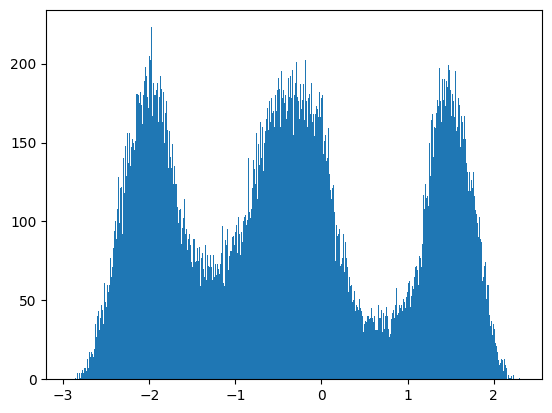

In [83]:
plt.hist(x_hat, bins=1000)
plt.show()

# Check Reconstruction

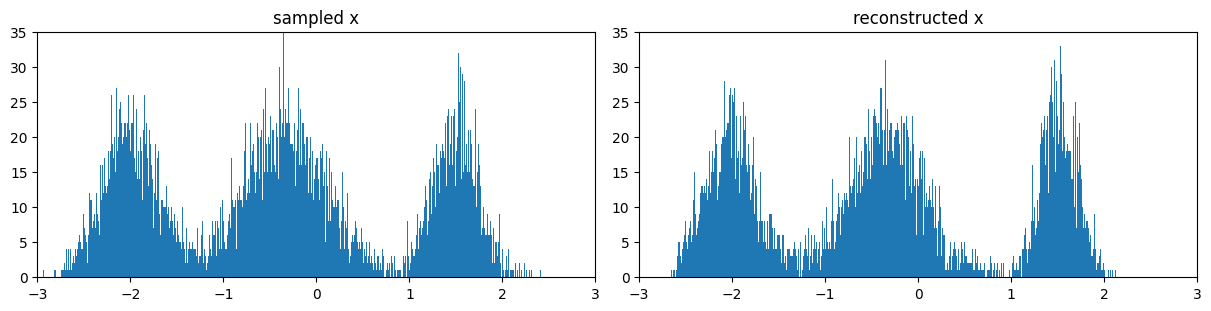

In [84]:
x = mixture_sample(10000)
x_pt = torch.from_numpy(x).float().view(-1, 1)
mu = encoder_mean(encoder(x_pt))
x_hat = decoder(mu).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 3), constrained_layout=True, dpi=100)
for ax in axes:
    ax.set_ylim(0, 35)
    ax.set_xlim(-3, 3)
axes[0].hist(x, bins=1000)
axes[0].set_title("sampled x")
axes[1].hist(x_hat, bins=1000)
axes[1].set_title("reconstructed x")
plt.show()